In [ ]:
import pandas as pd
# download https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset?select=employee_attrition_dataset_10000.csv
df = pd.read_csv('employee_attrition_dataset_10000.csv')

In [ ]:
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

## Preapare dataset

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

scaler_y = None

def prepare_data(df: pd.DataFrame, batch_size=64):
    global scaler_y
    x_cols = ['Age', 'Gender', 'Marital_Status', 'Distance_From_Home', 'Number_of_Companies_Worked']
    # Job_Satisfaction убран из y_cols, так как теперь это целевая метрика
    y_cols = ['Department', 'Job_Role', 'Job_Level', 'Monthly_Income', 'Overtime',
              'Work_Life_Balance', 'Project_Count', 'Training_Hours_Last_Year', 'Average_Hours_Worked_Per_Week']

    le = LabelEncoder()
    cat_cols = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    # --- ИЗМЕНЕНИЕ ЗДЕСЬ ---
    # Переводим Job_Satisfaction (1, 2, 3, 4) в Z (0.0, 0.33, 0.66, 1.0)
    satisfaction = df['Job_Satisfaction'].astype(float).values
    z = (satisfaction - 1.0) / 3.0

    scaler_x = StandardScaler()
    x_data = scaler_x.fit_transform(df[x_cols].values)

    scaler_y = StandardScaler()
    y_data = scaler_y.fit_transform(df[y_cols].values)

    # Стратификацию лучше проводить по исходным "сырым" оценкам
    X_train, X_test, Y_train, Y_test, Z_train, Z_test = train_test_split(
        x_data, y_data, z, test_size=0.2, random_state=42, stratify=satisfaction
    )

    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(Y_train), torch.FloatTensor(Z_train))
    test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(Y_test), torch.FloatTensor(Z_test))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, x_data.shape[1], y_data.shape[1]

In [ ]:
train_loader, test_loader, in_dim, out_dim = prepare_data(df)
len(train_loader), len(test_loader)

(125, 32)

In [ ]:
first_batch = next(iter(train_loader))
x_sample, y_sample, z_sample = first_batch

print("First 3 x examples:")
print(x_sample[:3])
print("\nFirst 3 y examples:")
print(y_sample[:3])
print("\nFirst 3 z examples:")
print(z_sample[:3])

First 3 x examples:
tensor([[-0.3110,  1.0084,  1.2329, -0.0191,  1.3317],
        [ 0.3875,  1.0084,  1.2329,  1.1061,  1.3317],
        [ 1.5224,  1.0084, -1.2243, -1.4961, -1.3615]])

First 3 y examples:
tensor([[ 0.6906,  1.3675,  0.0065,  0.7225,  1.0208,  0.4474, -1.1568,  1.5768,
         -1.5646],
        [ 0.6906, -1.3195,  0.7155, -0.4106, -0.9796,  0.4474,  0.3937,  0.3962,
         -1.1001],
        [ 1.3964,  0.4718, -1.4113,  0.8134, -0.9796,  0.4474, -0.3816,  1.0559,
         -1.3324]])

First 3 z examples:
tensor([0.3333, 1.3333, 0.0000])


## Models

In [ ]:
class JEPA(nn.Module):
    def __init__(self, x_dim: int, y_dim: int, embed_dim: int = 64):
        super().__init__()
        self.encoder_x = nn.Sequential(
            nn.Linear(x_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
        self.encoder_y = nn.Sequential(
            nn.Linear(y_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )

    def forward(self, x, y):
        h_x = self.encoder_x(x)
        h_y = self.encoder_y(y)
        return h_x, h_y

def jepa_loss(h_x: torch.Tensor, h_y: torch.Tensor, z: torch.Tensor, margin: float = 2.0) -> torch.Tensor:
    # MSE distance в латентном пространстве
    dist = torch.sum((h_x - h_y) ** 2, dim=1)

    # Z=1 (Успех): притягиваем
    pull_loss = z * dist
    # Z=0 (Провал): расталкиваем
    push_loss = (1 - z) * F.relu(margin - dist)

    return (pull_loss + push_loss).mean()

In [ ]:
class ConditionalGFlowNet(nn.Module):
    def __init__(self, embed_dim: int, y_dim: int):
        super().__init__()
        # Z_theta(X) - предсказывает начальную "массу" вариантов для конкретного пользователя
        self.logZ_predictor = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Авторегрессионный генератор (Forward Policy: P_F)
        # Вход: латент пользователя h_x. Выход: параметры для семплирования Y
        self.policy_net = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, y_dim * 2) # Выдаем mu и log_var для каждого признака среды
        )
        self.y_dim = y_dim

    def forward(self, h_x, target_y=None):
        logZ = self.logZ_predictor(h_x).squeeze(-1)

        params = self.policy_net(h_x)
        mu, log_var = torch.split(params, self.y_dim, dim=-1)
        log_var = torch.clamp(log_var, min=-5.0, max=0.0)
        std = torch.exp(0.5 * log_var)

        dist = torch.distributions.Normal(mu, std)

        if target_y is None:
            # Inference: генерируем новый вектор Y
            sampled_y = dist.rsample()
            log_pF = dist.log_prob(sampled_y).sum(dim=-1)
            return sampled_y, log_pF, logZ
        else:
            # Training: считаем вероятность P_F для уже известного исторического Y
            log_pF = dist.log_prob(target_y).sum(dim=-1)
            return target_y, log_pF, logZ

def tb_loss(logZ: torch.Tensor, log_pF: torch.Tensor, reward: torch.Tensor) -> torch.Tensor:
    # Trajectory Balance Loss: L = (log Z + log P_F - log R)^2
    # log P_B = 0, так как процесс генерации Y детерминирован в дереве
    log_reward = torch.log(reward + 1e-8)
    loss = (logZ + log_pF - log_reward) ** 2
    return loss.mean()

In [ ]:
def calculate_ood_modifier(y_sampled: torch.Tensor, y_min: torch.Tensor, y_max: torch.Tensor) -> torch.Tensor:
    """
    Рассчитывает штраф за выход признаков за границы реальных исторических данных.
    Возвращает коэффициент от 0.1 (строгий штраф) до 1.0 (штрафа нет).
    """
    # Булева маска выходов за границы (меньше минимума или больше максимума)
    out_of_bounds = (y_sampled < y_min) | (y_sampled > y_max)

    # Считаем долю нарушенных границ для каждого вектора Y в батче
    violation_rate = out_of_bounds.float().mean(dim=1)

    # Чем больше нарушений, тем меньше множитель награды
    modifier = torch.clamp(1.0 - violation_rate, min=0.1)
    return modifier

In [ ]:
import torch

def train_jepa(jepa, train_loader, test_loader, epochs=15, lr=1e-3):
    optimizer = torch.optim.Adam(jepa.parameters(), lr=lr)

    history = {'train': [], 'test': []}

    for epoch in range(epochs):
        # --- Обучение ---
        jepa.train()
        train_loss = 0.0
        for x, y, z in train_loader:
            optimizer.zero_grad()
            h_x, h_y = jepa(x, y)
            loss = jepa_loss(h_x, h_y, z)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        history['train'].append(avg_train_loss)

        # --- Валидация ---
        jepa.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, y, z in test_loader:
                h_x, h_y = jepa(x, y)
                loss = jepa_loss(h_x, h_y, z)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)
        history['test'].append(avg_test_loss)

        print(f"JEPA Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

    return jepa, history

In [ ]:
def train_gflownet(gfn, jepa, train_loader, test_loader, epochs=20, lr=1e-3, temperature=1.0):
    optimizer = torch.optim.Adam(gfn.parameters(), lr=lr)
    history = {'train': [], 'test': []}

    y_tensor_train = train_loader.dataset.tensors[1]
    y_min = y_tensor_train.min(dim=0)[0]
    y_max = y_tensor_train.max(dim=0)[0]

    for epoch in range(epochs):
        # --- Обучение ---
        gfn.train()
        jepa.eval()
        train_loss = 0.0
        valid_train_batches = 0

        for x, y, z in train_loader:
            # --- ИЗМЕНЕНИЕ ЗДЕСЬ ---
            # Отбираем траектории из кластеров с высокой удовлетворенностью (>= 3 из 4)
            success_mask = (z >= 0.66)
            if not success_mask.any(): continue
            x_succ, y_succ = x[success_mask], y[success_mask]

            optimizer.zero_grad()
            with torch.no_grad():
                h_x = jepa.encoder_x(x_succ)
                h_y = jepa.encoder_y(y_succ)
                dist = torch.sum((h_x - h_y)**2, dim=1)
                base_reward = torch.exp(-dist / temperature)
                final_reward = base_reward * calculate_ood_modifier(y_succ, y_min, y_max)

            _, log_pF, logZ = gfn(h_x, target_y=y_succ)
            loss = tb_loss(logZ, log_pF, final_reward)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(gfn.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            valid_train_batches += 1

        avg_train_loss = train_loss / valid_train_batches if valid_train_batches > 0 else 0
        history['train'].append(avg_train_loss)

        # --- Валидация ---
        gfn.eval()
        test_loss = 0.0
        valid_test_batches = 0

        with torch.no_grad():
            for x, y, z in test_loader:
                # --- ИЗМЕНЕНИЕ ЗДЕСЬ ---
                success_mask = (z >= 0.66)
                if not success_mask.any(): continue
                x_succ, y_succ = x[success_mask], y[success_mask]

                h_x = jepa.encoder_x(x_succ)
                h_y = jepa.encoder_y(y_succ)

                dist = torch.sum((h_x - h_y)**2, dim=1)
                base_reward = torch.exp(-dist / temperature)
                final_reward = base_reward * calculate_ood_modifier(y_succ, y_min, y_max)

                _, log_pF, logZ = gfn(h_x, target_y=y_succ)
                loss = tb_loss(logZ, log_pF, final_reward)

                test_loss += loss.item()
                valid_test_batches += 1

        avg_test_loss = test_loss / valid_test_batches if valid_test_batches > 0 else 0
        history['test'].append(avg_test_loss)

        print(f"GFN  Epoch {epoch+1:02d}/{epochs} | Train TB Loss: {avg_train_loss:.4f} | Test TB Loss: {avg_test_loss:.4f}")

    return gfn, history

## Visualize training

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(jepa_history, gfn_history):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    epochs_jepa = range(1, len(jepa_history['train']) + 1)
    epochs_gfn = range(1, len(gfn_history['train']) + 1)

    # --- График JEPA ---
    axes[0].plot(epochs_jepa, jepa_history['train'], label='Train Loss', color='blue', marker='o', markersize=5)
    axes[0].plot(epochs_jepa, jepa_history['test'], label='Test Loss', color='orange', marker='s', markersize=5)
    axes[0].set_title('JEPA Contrastive Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend()

    # --- График GFlowNet ---
    axes[1].plot(epochs_gfn, gfn_history['train'], label='Train TB Loss', color='green', marker='o', markersize=5)
    axes[1].plot(epochs_gfn, gfn_history['test'], label='Test TB Loss', color='red', marker='s', markersize=5)
    axes[1].set_title('GFlowNet Trajectory Balance Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
train_loader, test_loader, x_dim, y_dim = prepare_data(df, batch_size=128)

--- Обучение JEPA ---
JEPA Epoch 01/15 | Train Loss: 1.5725 | Test Loss: 0.8531
JEPA Epoch 02/15 | Train Loss: 0.7975 | Test Loss: 0.7567
JEPA Epoch 03/15 | Train Loss: 0.7345 | Test Loss: 0.7179
JEPA Epoch 04/15 | Train Loss: 0.7026 | Test Loss: 0.6963
JEPA Epoch 05/15 | Train Loss: 0.6877 | Test Loss: 0.6849
JEPA Epoch 06/15 | Train Loss: 0.6777 | Test Loss: 0.6774
JEPA Epoch 07/15 | Train Loss: 0.6711 | Test Loss: 0.6716
JEPA Epoch 08/15 | Train Loss: 0.6668 | Test Loss: 0.6682
JEPA Epoch 09/15 | Train Loss: 0.6637 | Test Loss: 0.6653
JEPA Epoch 10/15 | Train Loss: 0.6607 | Test Loss: 0.6624
JEPA Epoch 11/15 | Train Loss: 0.6587 | Test Loss: 0.6607
JEPA Epoch 12/15 | Train Loss: 0.6564 | Test Loss: 0.6590
JEPA Epoch 13/15 | Train Loss: 0.6557 | Test Loss: 0.6578
JEPA Epoch 14/15 | Train Loss: 0.6558 | Test Loss: 0.6569
JEPA Epoch 15/15 | Train Loss: 0.6535 | Test Loss: 0.6556

--- Обучение GFlowNet ---
GFN  Epoch 01/20 | Train TB Loss: 152.7393 | Test TB Loss: 142.2486
GFN  Epoch 02

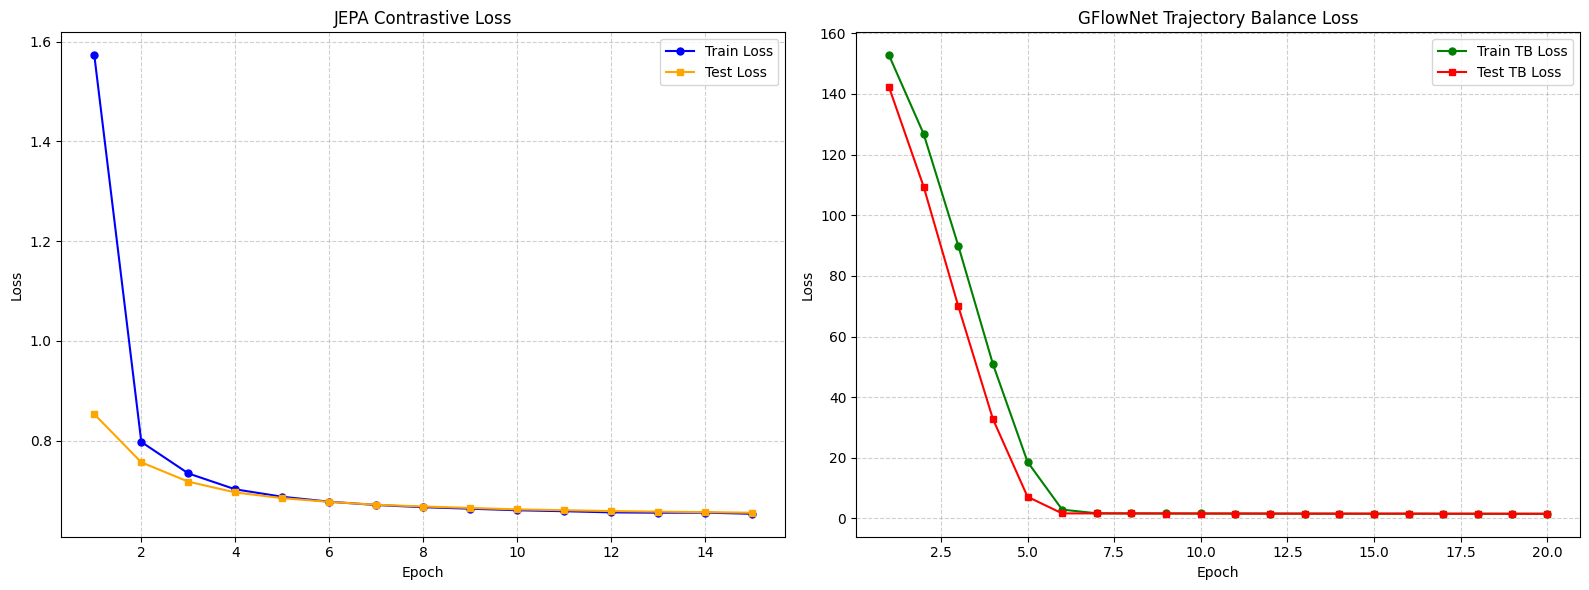

In [ ]:
# Инициализация и запуск
jepa_model = JEPA(x_dim=x_dim, y_dim=y_dim, embed_dim=64)
gfn_model = ConditionalGFlowNet(embed_dim=64, y_dim=y_dim)

print("--- Обучение JEPA ---")
jepa_model, jepa_hist = train_jepa(jepa_model, train_loader, test_loader, epochs=15, lr=1e-3)

print("\n--- Обучение GFlowNet ---")
gfn_model, gfn_hist = train_gflownet(gfn_model, jepa_model, train_loader, test_loader, epochs=20, lr=1e-3)

# Отрисовка обновленных графиков
plot_training_curves(jepa_hist, gfn_hist)

## Visualize GFlowNet action space

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def get_real_gfn_probabilities(jepa_model, gfn_model, x_user, feature_idx, scaled_class_values):
    """
    Извлекает реальные вероятности из обученного непрерывного GFlowNet.

    x_user: тензор (1, x_dim) реального пользователя из test_loader
    feature_idx: индекс метрики в векторе Y (например, 0 для Department)
    scaled_class_values: список отмасштабированных значений (куда scaler_y перевел 0, 1, 2...)
    """
    jepa_model.eval()
    gfn_model.eval()

    with torch.no_grad():
        # Извлекаем реальный каузальный интент
        h_x = jepa_model.encoder_x(x_user)

        # Получаем параметры распределений от GFlowNet
        predicted_params = gfn_model.policy_net(h_x)
        y_dim = predicted_params.shape[1] // 2

        mu = predicted_params[0, feature_idx].item()
        log_var = predicted_params[0, feature_idx + y_dim].item()
        sigma = np.exp(0.5 * log_var) + 1e-6 # Защита от деления на ноль

    # Вычисляем плотность вероятности (PDF) для каждого класса
    probs = []
    # print(f"Признак {feature_idx} | mu: {mu:.3f} | log_var: {log_var:.3f} | sigma: {sigma:.3f}")
    for val in scaled_class_values:
        # Используем формулу Гаусса (коэффициент 1/(sigma*sqrt(2pi)) можно опустить,
        # так как мы всё равно будем нормализовать сумму до 1)
        p = np.exp(-0.5 * ((val - mu) / sigma)**2)
        probs.append(p)

    probs = np.array(probs)
    # Нормализуем, чтобы получить распределение вероятностей ветвей графа
    return probs / np.sum(probs)

In [ ]:
# Предполагаем, что у вас в памяти есть обученные jepa_model, gfn_model и test_loader,
# а также объект scaler_y, обученный на колонках Y.

# Индексы колонок в векторе Y (определяются порядком в y_cols при подготовке данных)
# 'Department' -> 0, 'Overtime' -> 4, 'Work_Life_Balance' -> 5
IDX_DEPT = 0
IDX_OVERTIME = 4
IDX_WLB = 5

# Вспомогательная функция для получения отмасштабированного значения класса
def get_scaled_value(scaler, feature_idx, raw_value, y_dim):
    dummy_row = np.zeros((1, y_dim))
    dummy_row[0, feature_idx] = raw_value
    return scaler.transform(dummy_row)[0, feature_idx]

y_dim = 9 # Количество фичей в Y

# Описываем реальные шаги с учетом трансформации данных
real_feature_metadata = [
    {
        'name': 'Department',
        'options': ['Sales (0)', 'R&D (1)', 'HR (2)'],
        'scaled_vals': [get_scaled_value(scaler_y, IDX_DEPT, v, y_dim) for v in [0, 1, 2]],
        'y_idx': IDX_DEPT
    },
    {
        'name': 'Overtime',
        'options': ['No (0)', 'Yes (1)'],
        'scaled_vals': [get_scaled_value(scaler_y, IDX_OVERTIME, v, y_dim) for v in [0, 1]],
        'y_idx': IDX_OVERTIME
    },
    {
        'name': 'Work_Life_Balance',
        'options': ['Bad (1)', 'Good (2)', 'Better (3)', 'Best (4)'],
        'scaled_vals': [get_scaled_value(scaler_y, IDX_WLB, v, y_dim) for v in [1, 2, 3, 4]],
        'y_idx': IDX_WLB
    }
]

In [ ]:
def visualize_real_gflownet_graph(jepa_model, gfn_model, test_loader, feature_metadata, id=1):
    # 1. Берем пользователя из тестовой выборки
    it = iter(test_loader)
    for i in range(id):
        x_batch, y_batch, z_batch = next(it)
    success_indices = (z_batch >= 0.66).nonzero(as_tuple=True)[0]
    target_idx = success_indices[0] if len(success_indices) > 0 else 0
    x_user = x_batch[target_idx].unsqueeze(0)

    print("--- Анализ реального профиля ---")

    # 2. Сбор реальных вероятностей
    real_probs = []
    selected_path = []
    for feat in feature_metadata:
        probs = get_real_gfn_probabilities(jepa_model, gfn_model, x_user, feat['y_idx'], feat['scaled_vals'])
        real_probs.append(probs)
        chosen_idx = np.random.choice(len(feat['options']), p=probs)
        selected_path.append(feat['options'][chosen_idx])

    # 3. Строим чистые идентификаторы пути через кортежи
    chosen_path_tuples = [()]
    current_tuple = ()
    for opt in selected_path:
        current_tuple = current_tuple + (opt,)
        chosen_path_tuples.append(current_tuple)

    # 4. Построение Графа
    G = nx.DiGraph()

    # Корневой узел
    root_id = ()
    G.add_node(root_id, label="Старт")
    pos = {root_id: (0, 0)}

    current_parent = root_id

    for step_idx, feat in enumerate(feature_metadata):
        options = feat['options']
        probs = real_probs[step_idx]

        for opt_idx, option in enumerate(options):
            # ID узла — это уникальный кортеж истории выбора
            node_id = current_parent + (option,)

            # --- ИЗМЕНЕНИЕ ЗДЕСЬ ---
            # Теперь имя признака ВСЕГДА пишется в лейбл узла, независимо от шага
            node_label = f"{feat['name']}:\n{option}"

            G.add_node(node_id, label=node_label)

            # Проверка на принадлежность к выбранному пути
            is_chosen = (current_parent == chosen_path_tuples[step_idx] and
                         node_id == chosen_path_tuples[step_idx + 1])

            G.add_edge(current_parent, node_id, weight=probs[opt_idx], chosen=is_chosen)

            # Вычисление координат (центрирование относительно родителя)
            parent_x = pos[current_parent][0]
            width = len(options)
            x_coord = parent_x + (opt_idx - (width - 1) / 2) * 2.5 # Чуть увеличил шаг, чтобы узлы не перекрывались
            pos[node_id] = (x_coord, -(step_idx + 1) * 2.5)

        # Сдвигаем родителя по выбранной траектории дальше
        current_parent = chosen_path_tuples[step_idx + 1]

    # 5. Отрисовка
    plt.figure(figsize=(16, 9)) # Немного увеличил размер полотна
    edges = G.edges(data=True)
    chosen_edges = [(u, v) for u, v, d in edges if d['chosen']]
    other_edges = [(u, v) for u, v, d in edges if not d['chosen']]

    # Печатаем чистый список выбранных ребер в консоль (заменяем перенос строки на пробел для компактности в логах)
    for u, v in chosen_edges:
        label_u = G.nodes[u]['label'].replace('\n', ' ')
        label_v = G.nodes[v]['label'].replace('\n', ' ')

    # Рисуем узлы
    nx.draw_networkx_nodes(G, pos, node_size=3200, node_color="#eef2f7", linewidths=2)

    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family="sans-serif", font_weight="bold")

    # Рисуем стрелки
    nx.draw_networkx_edges(G, pos, edgelist=chosen_edges, width=3, edge_color="#2ca02c", arrows=True, arrowsize=20)
    nx.draw_networkx_edges(G, pos, edgelist=other_edges, width=1.5, edge_color="#94a3b8", style="dashed", arrows=True)

    # Вероятности на ребрах
    edge_labels = {(u, v): f"{d['weight']*100:.1f}%" for u, v, d in G.edges(data=True)}
    # print(edge_labels)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color="#1e293b", font_weight="bold")

    plt.title("Дерево решений (Реальные данные обученных JEPA + GFlowNet)", fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

--- Анализ реального профиля ---


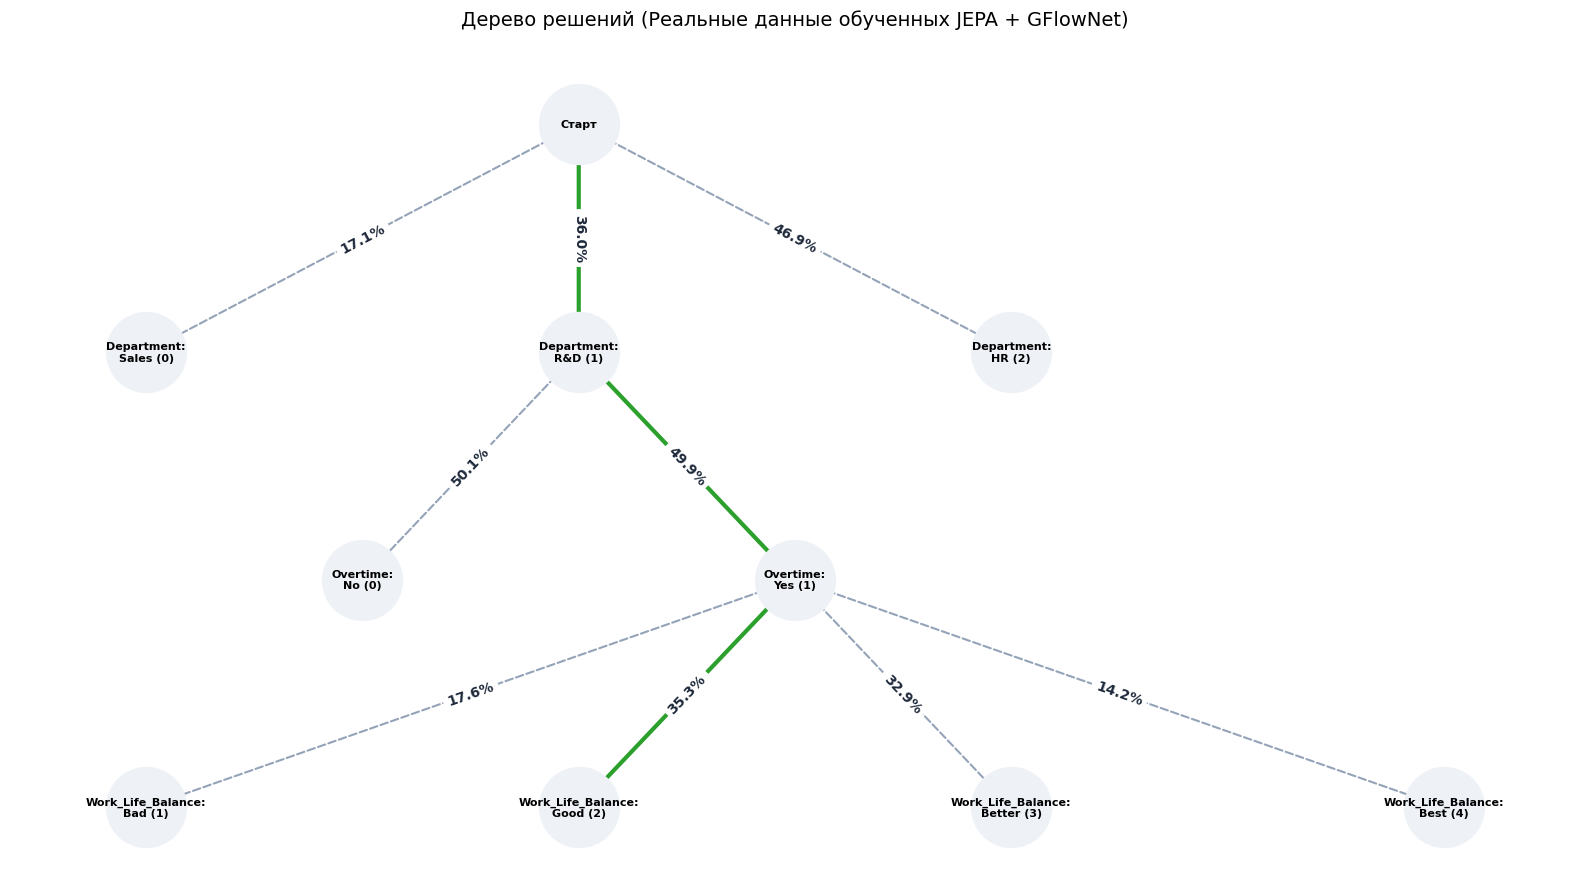

In [ ]:
visualize_real_gflownet_graph(jepa_model, gfn_model, test_loader, real_feature_metadata, 8)

## Check custom metrics: accuracy, diversity, efficacy

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
from itertools import product

def generate_all_combinations(feature_metadata):
    """
    Генерирует все возможные дискретные комбинации признаков среды Y
    и их отмасштабированные значения для подачи в модели.
    """
    options_list = [feat['options'] for feat in feature_metadata]
    scaled_list = [feat['scaled_vals'] for feat in feature_metadata]

    # Все текстовые/дискретные комбинации
    all_raw_combos = list(product(*options_list))
    # Все соответствующие им отмасштабированные векторы (для предсказаний)
    all_scaled_combos_subset = np.array(list(product(*scaled_list)))

    return all_raw_combos, all_scaled_combos_subset

def get_gflownet_joint_distribution(jepa_model, gfn_model, x_user, feature_metadata):
    """
    Рассчитывает полную совместную вероятность P_GFN(Y|X) для всех возможных комбинаций Y.
    """
    jepa_model.eval()
    gfn_model.eval()

    # Извлекаем вероятности для каждого шага независимо (как в исходном инференсе)
    step_probabilities = []
    with torch.no_grad():
        for feat in feature_metadata:
            # Используем ранее написанную функцию для извлечения гауссовых вероятностей класса
            probs = get_real_gfn_probabilities(jepa_model, gfn_model, x_user, feat['y_idx'], feat['scaled_vals'])
            step_probabilities.append(probs)

    # Перемножаем вероятности шагов для получения честной вероятности траектории P(Y|X) = P(y1)*P(y2)*P(y3)
    options_indices = [range(len(feat['options'])) for feat in feature_metadata]
    all_joint_probs = []

    for idx_tuple in product(*options_indices):
        joint_p = 1.0
        for step_idx, opt_idx in enumerate(idx_tuple):
            joint_p *= step_probabilities[step_idx][opt_idx]
        all_joint_probs.append(joint_p)

    return np.array(all_joint_probs) / np.sum(all_joint_probs)

def get_tree_joint_distribution(tree_model, x_user_raw,
        y_user_raw, all_scaled_combos_subset, feature_metadata, y_dim, temperature=0.1):
    """
    Формирует распределение вероятностей на основе предсказаний Дерева Решений.
    Применяет Softmax к предсказанным наградам, чтобы получить вероятностный аналог.
    """
    # Дублируем вектор пользователя под количество комбинаций среды
    num_combos = len(all_scaled_combos_subset)
    x_matrix = np.repeat(x_user_raw.reshape(1, -1), num_combos, axis=0)

    # Construct the full Y vectors for each combination
    y_full_vectors = np.zeros((num_combos, y_dim))

    # Initialize with the user's original y values (for features not being varied)
    # This broadcasts y_user_raw to all rows of y_full_vectors
    y_full_vectors += y_user_raw

    # Overwrite the features that are being varied according to feature_metadata
    feat_indices = [feat['y_idx'] for feat in feature_metadata]

    for i, combo_subset in enumerate(all_scaled_combos_subset):
        for j, feat_val in enumerate(combo_subset):
            y_full_vectors[i, feat_indices[j]] = feat_val

    # On input to the tree, it is a concatenation of [X, Y]
    tree_input = np.hstack([x_matrix, y_full_vectors])

    # Predicted satisfaction (Reward) for each option
    predicted_rewards = tree_model.predict(tree_input)

    # Convert rewards to probabilities using Softmax with temperature
    # The smaller the temperature, the more the tree will peak at one best option
    exp_rewards = np.exp(predicted_rewards / temperature)
    return exp_rewards / np.sum(exp_rewards), predicted_rewards

In [ ]:
def calculate_l1_tv_distance(p_model, p_true):
    """
    Метрика Точности: Total Variation Distance (L1 норма между распределениями).
    Показывает, насколько точно модель воспроизводит ландшафт истинных наград.
    0.0 — идеальное совпадение, 1.0 — полное расхождение.
    """
    return 0.5 * np.sum(np.abs(p_model - p_true))

def calculate_shannon_entropy(p_distribution):
    """
    Метрика Разнообразия: Информационная энтропия Шеннона.
    Показывает, способна ли модель предлагать альтернативы (высокая энтропия)
    или она сколлапсировала в одну точку (нулевая энтропия).
    """
    return -np.sum(p_distribution * np.log2(p_distribution + 1e-9))

def calculate_top_k_efficiency(p_distribution, true_rewards, k=3):
    """
    Метрика Эффективности: Средняя истинная награда топ-K вариантов,
    выбранных моделью (с наибольшей вероятностью).
    """
    top_k_indices = np.argsort(p_distribution)[-k:]
    return np.mean(true_rewards[top_k_indices])

In [ ]:

from sklearn.ensemble import RandomForestRegressor

def run_evaluation_pipeline(jepa_model, gfn_model, train_loader, test_loader, feature_metadata, k_eff=3):
    print("1. Обучение НЕЗАВИСИМОГО Оракула (Random Forest)...")
    x_train, y_train, z_train = train_loader.dataset.tensors
    x_train_np, y_train_np, z_train_np = x_train.numpy(), y_train.numpy(), z_train.numpy()
    tree_input_train = np.hstack([x_train_np, y_train_np])

    # Этот мощный ансамбль будет "истинной средой" для расчета p_true и Top-K Reward
    oracle_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
    oracle_model.fit(tree_input_train, z_train_np)

    print("2. Обучение СЛАБОГО БЕЙЗЛАЙНА (Decision Tree)...")
    # А это наш подопытный baseline, с которым мы соревнуемся
    baseline_tree = DecisionTreeRegressor(max_depth=4, random_state=42)
    baseline_tree.fit(tree_input_train, z_train_np)

    all_raw_combos, all_scaled_combos_subset = generate_all_combinations(feature_metadata)

    metrics_summary = {
        'gfn_l1': [], 'tree_l1': [],
        'gfn_entropy': [], 'tree_entropy': [],
        'gfn_topk_reward': [], 'tree_topk_reward': []
    }

    x_test, y_test, z_test = test_loader.dataset.tensors
    success_indices = (z_test >= 0.66).nonzero(as_tuple=True)[0].numpy()

    y_dim_full = y_train.shape[1]


    print(f"3. Запуск тестирования на {len(success_indices)} пользователях...")
    for idx in success_indices:
        x_user_tensor = x_test[idx].unsqueeze(0)
        x_user_np = x_test[idx].numpy()
        y_user_np = y_test[idx].numpy()

        # --- ИЗМЕНЕНИЕ ЗДЕСЬ ---
        # Истинные награды и таргет распределение считает НЕЗАВИСИМЫЙ Оракул
        _, true_rewards = get_tree_joint_distribution(oracle_model, x_user_np, y_user_np, all_scaled_combos_subset, feature_metadata, y_dim_full)
        exp_true = np.exp(true_rewards / 0.05)
        p_true_target = exp_true / np.sum(exp_true) # Softmax ради честности сравнения

        # GFlowNet генерирует свой поток
        p_gfn = get_gflownet_joint_distribution(jepa_model, gfn_model, x_user_tensor, feature_metadata)

        # Бейзлайн (Дерево) генерирует свои предсказания (температуру ставим жестче, например 0.05, чтобы убрать плоский шум)
        p_tree, _ = get_tree_joint_distribution(baseline_tree, x_user_np, y_user_np, all_scaled_combos_subset, feature_metadata, y_dim_full, temperature=0.05)

        if idx == success_indices[0]:
            print(f"\n[Диагностика] Диапазон предсказаний Оракула: мин={true_rewards.min():.4f}, макс={true_rewards.max():.4f}, std={true_rewards.std():.4f}")
            print(f"[Диагностика] Первые 5 вероятностей GFlowNet: {p_gfn[:5]}")
            print(f"[Диагностика] Первые 5 вероятностей Дерева: {p_tree[:5]}")
        # Считаем метрики (оценка идет по true_rewards от Оракула)
        metrics_summary['gfn_l1'].append(calculate_l1_tv_distance(p_gfn, p_true_target))
        metrics_summary['tree_l1'].append(calculate_l1_tv_distance(p_tree, p_true_target))

        metrics_summary['gfn_entropy'].append(calculate_shannon_entropy(p_gfn))
        metrics_summary['tree_entropy'].append(calculate_shannon_entropy(p_tree))

        metrics_summary['gfn_topk_reward'].append(calculate_top_k_efficiency(p_gfn, true_rewards, k=k_eff))
        metrics_summary['tree_topk_reward'].append(calculate_top_k_efficiency(p_tree, true_rewards, k=k_eff))

        # Считаем метрики
        metrics_summary['gfn_l1'].append(calculate_l1_tv_distance(p_gfn, p_true_target))
        metrics_summary['tree_l1'].append(calculate_l1_tv_distance(p_tree, p_true_target))

        metrics_summary['gfn_entropy'].append(calculate_shannon_entropy(p_gfn))
        metrics_summary['tree_entropy'].append(calculate_shannon_entropy(p_tree))

        metrics_summary['gfn_topk_reward'].append(calculate_top_k_efficiency(p_gfn, true_rewards, k=k_eff))
        metrics_summary['tree_topk_reward'].append(calculate_top_k_efficiency(p_tree, true_rewards, k=k_eff))

    # Формируем красивую финальную таблицу
    report = pd.DataFrame({
        'Метрика (Среднее)': ['Точность (L1 / TV Distance) ↓', 'Разнообразие (Entropy) ↑', f'Эффективность (Top-{k_eff} Reward) ↑'],
        'Conditional GFlowNet': [
            np.mean(metrics_summary['gfn_l1']),
            np.mean(metrics_summary['gfn_entropy']),
            np.mean(metrics_summary['gfn_topk_reward'])
        ],
        'Decision Tree (Baseline)': [
            np.mean(metrics_summary['tree_l1']),
            np.mean(metrics_summary['tree_entropy']),
            np.mean(metrics_summary['tree_topk_reward'])
        ]
    })

    print("\n=== ФИНАЛЬНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ ===")
    return report

In [ ]:
# Передаем обученные модели, лоадеры данных и метаданные дискретных шагов
report_df = run_evaluation_pipeline(
    jepa_model=jepa_model,
    gfn_model=gfn_model,
    train_loader=train_loader,
    test_loader=test_loader,
    feature_metadata=real_feature_metadata,
    k_eff=3
)

1. Обучение НЕЗАВИСИМОГО Оракула (Random Forest)...
2. Обучение СЛАБОГО БЕЙЗЛАЙНА (Decision Tree)...
3. Запуск тестирования на 1224 пользователях...

[Диагностика] Диапазон предсказаний Оракула: мин=0.6106, макс=0.6692, std=0.0130
[Диагностика] Первые 5 вероятностей GFlowNet: [0.01438432 0.02985635 0.0287639  0.01286241 0.0138136 ]
[Диагностика] Первые 5 вероятностей Дерева: [0.04166667 0.04166667 0.04166667 0.04166667 0.04166667]

=== ФИНАЛЬНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ ===


In [ ]:
# Вывод результатов
# import className
# from transform_table import display
# display(report_df.round(4))
report_df.round(4)

,Метрика (Среднее),Conditional GFlowNet,Decision Tree (Baseline)
0,Точность (L1 / TV Distance) ↓,0.2463,0.0999
1,Разнообразие (Entropy) ↑,4.3814,4.5467
2,Эффективность (Top-3 Reward) ↑,0.6817,0.6765
